In [1]:
using Printf

In [14]:
using SparseArrays
using QuantumOptics
using PyPlot
using QuantumCumulants
using SpecialFunctions

include("PlotSetup.jl")

"""
    block_ranges(space::SumBasis)

Given a direct sum basis `space`, returns a vector of UnitRange{Int},
where each element gives the global index range corresponding to each subspace.
"""
function block_ranges(space::SumBasis)
    ranges = Vector{UnitRange{Int}}(undef, length(space.shape))
    start = 1
    for (i, len) in enumerate(space.shape)
        ranges[i] = start:(start+len-1)
        start += len
    end
    return ranges
end


"""
    build_operator(N, matrix_element)

Constructs a sparse operator over the Dicke Hilbert space (direct sum of SpinBasis blocks)
for a system of N atoms. The input `matrix_element` is a function with signature

    matrix_element(N, J, M, Jp, Mp) -> ComplexF64

which returns the matrix element connecting state |J, M⟩ in one block to |Jp, Mp⟩ in another.
Only nonzero values are stored.

Returns a tuple (op, space) where `op` is the operator (sparse matrix) and `space` is
the constructed SumBasis.
"""
function build_operator(N::Int, matrix_element::Function)
    # Construct the Dicke Hilbert space as a direct sum of SpinBasis blocks.
    subs = dicke_subspaces(N)         # vector of SpinBasis for each allowed J
    space = directsum(subs...)          # the full SumBasis
    total_dim = length(space)           # total dimension of the Hilbert space
    op = spzeros(ComplexF64, total_dim, total_dim)
    
    # Obtain global index ranges for each block in the direct sum.
    br = block_ranges(space)
    
    # Loop over all pairs of blocks: source block (with spin J) and target block (with spin Jp)
    for (i, b_source) in enumerate(subs)
        J = b_source.spinnumber
        dim_source = length(b_source)   # dimension = 2J + 1
        for (j, b_target) in enumerate(subs)
            Jp = b_target.spinnumber
            dim_target = length(b_target)  # dimension = 2Jp + 1
            
            # Get the global index ranges for these blocks.
            range_source = br[i]
            range_target = br[j]
            
            # Loop over basis states in the source block.
            # Convention: basis index k corresponds to M = J - (k - 1)
            for k_source in 1:dim_source
                M = J - (k_source - 1)
                # And similarly for the target block:
                for k_target in 1:dim_target
                    Mp = Jp - (k_target - 1)
                    val = matrix_element(N, J, M, Jp, Mp)
                    if val != 0
                        global_source = range_source[k_source]
                        global_target = range_target[k_target]
                        op[global_target, global_source] = val
                    end
                end
            end
        end
    end
    return SparseOperator(space, op)
end

function matrix_element_collective_decay(N, J, M, Jp, Mp)
    # Nonzero only if J remains the same and Mp = M - 1.
    if J == Jp && Mp == M - 1
        return A_JM_minus(J, M)
    else
        return 0.0
    end
end

# Collective factors (used also in the individual channels):
"""
    A_JM_minus(J, M)

Collective lowering amplitude:
  A_{JM}⁻ = √[(J + M)(J – M + 1)]
"""
A_JM_minus(J, M) = sqrt((J + M) * (J - M + 1))

"""
    A_JM_plus(J, M)

Collective raising amplitude:
  A_{JM}⁺ = √[(J – M)(J + M + 1)]
"""
A_JM_plus(J, M) = sqrt((J - M) * (J + M + 1))

# ---------------------------
# Individual Decay (lowering M)
# ---------------------------

"""
    P_JM_minus_0(J, M, N)

Individual decay channel with no change in J:
  P_{JM}^{-,0} = √[(2+N)/(4J(J+1))] A_{JM}⁻.
"""
P_JM_minus_0(J, M, N) = sqrt((2 + N) / (4 * J * (J + 1))) * A_JM_minus(J, M)

"""
    P_JM_minus_minus(J, M, N)

Individual decay channel lowering J by 1 (“s = -1”):
  P_{JM}^{-,-} = -√[(N+2J+2)(J+M)(J+M-1)/(4J(2J+1))].
"""
P_JM_minus_minus(J, M, N) = -sqrt((N + 2 * J + 2) * (J + M) * (J + M - 1) / (4 * J * (2 * J + 1)))

"""
    P_JM_minus_plus(J, M, N)

Individual decay channel increasing J by 1 (“s = +1”):
  P_{JM}^{-,+} = √[(N-2J)(J-M+1)(J-M+2)/(4(J+1)(2J+1))].
"""
P_JM_minus_plus(J, M, N) = sqrt((N - 2 * J) * (J - M + 1) * (J - M + 2) / (4 * (J + 1) * (2 * J + 1)))

# ---------------------------
# Individual Pumping (raising M)
# ---------------------------

"""
    P_JM_plus_0(J, M, N)

Individual pumping channel with no change in J:
  P_{JM}^{+,0} = √[(2+N)/(4J(J+1))] A_{JM}⁺.
"""
P_JM_plus_0(J, M, N) = sqrt((2 + N) / (4 * J * (J + 1))) * A_JM_plus(J, M)

"""
    P_JM_plus_minus(J, M, N)

Individual pumping channel lowering J by 1 (“s = -1”):
  P_{JM}^{+,-} = √[(N+2J+2)(J-M)(J-M-1)/(4J(2J+1))].
"""
P_JM_plus_minus(J, M, N) = sqrt((N + 2 * J + 2) * (J - M) * (J - M - 1) / (4 * J * (2 * J + 1)))

"""
    P_JM_plus_plus(J, M, N)

Individual pumping channel increasing J by 1 (“s = +1”):
  P_{JM}^{+,+} = -√[(N-2J)(J+M+1)(J+M+2)/(4(J+1)(2J+1))].
"""
P_JM_plus_plus(J, M, N) = -sqrt((N - 2 * J) * (J + M + 1) * (J + M + 2) / (4 * (J + 1) * (2 * J + 1)))

# ---------------------------
# Individual Dephasing
# ---------------------------

"""
    P_JM_z_0(J, M, N)

Individual dephasing channel that leaves M unchanged:
  P_{JM}^{z,0} = √[(2+N)/(4J(J+1))] M.
"""
function P_JM_z_0(J, M, N)
    if J == 0
        return 0.0
    else
        return sqrt((2 + N) / (4 * J * (J + 1))) * M
    end
end
#P_JM_z_0(J, M, N) = sqrt((2 + N) / (4 * J * (J + 1))) * M

"""
    P_JM_z_minus(J, M, N)

Individual dephasing channel lowering J by 1 (“s = -”):
  P_{JM}^{z,-} = √[(N+2J+2)(J-M)(J+M)/(4J(2J+1))].
"""
P_JM_z_minus(J, M, N) = sqrt((N + 2 * J + 2) * (J - M) * (J + M) / (4 * J * (2 * J + 1)))

"""
    P_JM_z_plus(J, M, N)

Individual dephasing channel increasing J by 1 (“s = +”):
  P_{JM}^{z,+} = √[(N-2J)(J+1-M)(J+1+M)/(4(J+1)(2J+1))].
"""
P_JM_z_plus(J, M, N) = sqrt((N - 2 * J) * (J + 1 - M) * (J + 1 + M) / (4 * (J + 1) * (2 * J + 1)))


"""
d_N_J(N, J)

Returns the degeneracy factor for a Dicke state with N atoms and total spin J,
defined by

  d_N^J = (N! (2J+1)) / ((N/2 - J)! (N/2 + J + 1)!)
      = Γ(N+1) (2J+1) / (Γ(N/2 - J + 1) Γ(N/2 + J + 2))
"""
function d_N_J(N::Int, J::Real)
    return 1.0 #gamma(N + 1) * (2 * J + 1) / (gamma(N/2 - J + 1) * gamma(N/2 + J + 2))
end

allowed_J(N) = (N % 2 == 0) ? collect(0:1:N÷2) : collect(1//2:1:N÷2)


# Create a list of SpinBasis subspaces for the allowed total spins
function dicke_subspaces(N::Int)
    js = (N % 2 == 0) ? [j for j in 0:N÷2] : [j//2 for j in 1:2:N]
    return reverse([SpinBasis(j) for j in js])
end

# Full Dicke Hilbert space as a direct sum
function dicke_space(N::Int)
    return directsum(dicke_subspaces(N)...)
end

# -- Matrix Element Functions for Jump Operators --

# 1. Collective Decay (acts within the same J, lowering M by 1)
function matrix_element_collective_decay(N, J, M, Jp, Mp)
    if J == Jp && Mp == M - 1
        # Multiply by sqrt(degeneracy) for the source block.
        return sqrt(d_N_J(N, J)) * A_JM_minus(J, M)
    else
        return 0.0
    end
end

# 2. Individual Decay, s = 0 channel (no change in J, lowering M by 1)
function matrix_element_individual_decay_s0(N, J, M, Jp, Mp)
    if J == Jp && Mp == M - 1
        return sqrt(d_N_J(N, J)) * P_JM_minus_0(J, M, N)
    else
        return 0.0
    end
end

# 3. Individual Decay, s = -1 channel (J -> J-1, lowering M by 1)
function matrix_element_individual_decay_sminus(N, J, M, Jp, Mp)
    if Jp == J - 1 && Mp == M - 1
        return sqrt(d_N_J(N, J)) * P_JM_minus_minus(J, M, N)
    else
        return 0.0
    end
end

# 4. Individual Decay, s = +1 channel (J -> J+1, lowering M by 1)
function matrix_element_individual_decay_splus(N, J, M, Jp, Mp)
    if Jp == J + 1 && Mp == M - 1
        return sqrt(d_N_J(N, J)) * P_JM_minus_plus(J, M, N)
    else
        return 0.0
    end
end


# 1. Individual Pumping Operators:

# s = 0: No change in J, M → M+1.
function matrix_element_individual_pump_s0(N, J, M, Jp, Mp)
    if J == Jp && Mp == M + 1
        return sqrt(d_N_J(N, J)) * P_JM_plus_0(J, M, N)
    else
        return 0.0
    end
end

# s = -1: J → J - 1, M → M+1.
function matrix_element_individual_pump_sminus(N, J, M, Jp, Mp)
    if Jp == J - 1 && Mp == M + 1
        return sqrt(d_N_J(N, J)) * P_JM_plus_minus(J, M, N)
    else
        return 0.0
    end
end

# s = +1: J → J + 1, M → M+1.
function matrix_element_individual_pump_splus(N, J, M, Jp, Mp)
    if Jp == J + 1 && Mp == M + 1
        return sqrt(d_N_J(N, J)) * P_JM_plus_plus(J, M, N)
    else
        return 0.0
    end
end

# 2. Individual Dephasing Operators:

# s = 0: No change in J, M unchanged.
function matrix_element_individual_dephase_s0(N, J, M, Jp, Mp)
    if J == Jp && Mp == M
        return sqrt(d_N_J(N, J)) * P_JM_z_0(J, M, N)
    else
        return 0.0
    end
end

# s = -: J → J - 1, M unchanged.
function matrix_element_individual_dephase_sminus(N, J, M, Jp, Mp)
    if Jp == J - 1 && Mp == M
        return sqrt(d_N_J(N, J)) * P_JM_z_minus(J, M, N)
    else
        return 0.0
    end
end

# s = +: J → J + 1, M unchanged.
function matrix_element_individual_dephase_splus(N, J, M, Jp, Mp)
    if Jp == J + 1 && Mp == M
        return sqrt(d_N_J(N, J)) * P_JM_z_plus(J, M, N)
    else
        return 0.0
    end
end

QuantumOptics.sigmam(hilbert_space::SumBasis) = directsum(sigmam.(hilbert_space.bases)...)
QuantumOptics.sigmap(hilbert_space::SumBasis) = directsum(sigmap.(hilbert_space.bases)...)
QuantumOptics.sigmax(hilbert_space::SumBasis) = directsum(sigmax.(hilbert_space.bases)...)
QuantumOptics.sigmay(hilbert_space::SumBasis) = directsum(sigmay.(hilbert_space.bases)...)
QuantumOptics.sigmaz(hilbert_space::SumBasis) = directsum(sigmaz.(hilbert_space.bases)...)
QuantumOptics.identityoperator(hilbert_space::SumBasis) = directsum(identityoperator.(hilbert_space.bases)...)

function build_collapse_operators(N::Int, Γ_c, γ_l, κ_l, d_l)
    # Get the common Hilbert space for N atoms.
    common_space = dicke_space(N)
    
    # Initialize empty lists for operators and rates.
    op_list::Vector = []
    rate_list::Vector = []
    
    # 1. Collective decay operator (rate: Γ_c)
    push!(op_list, build_operator(N, matrix_element_collective_decay))
    push!(rate_list, Γ_c)
    
    # 2. Individual decay operators (rate: γ_l)
    push!(op_list, build_operator(N, matrix_element_individual_decay_s0))
    push!(rate_list, γ_l)
    
    push!(op_list, build_operator(N, matrix_element_individual_decay_sminus))
    push!(rate_list, γ_l)
    
    push!(op_list, build_operator(N, matrix_element_individual_decay_splus))
    push!(rate_list, γ_l)
    
    # 3. Individual pumping operators (rate: κ_l)
    push!(op_list, build_operator(N, matrix_element_individual_pump_s0))
    push!(rate_list, κ_l)
    
    push!(op_list, build_operator(N, matrix_element_individual_pump_sminus))
    push!(rate_list, κ_l)
    
    push!(op_list, build_operator(N, matrix_element_individual_pump_splus))
    push!(rate_list, κ_l)
    
    # 4. Individual dephasing operators (rate: d_l)
    push!(op_list, build_operator(N, matrix_element_individual_dephase_s0))
    push!(rate_list, d_l)
    
    push!(op_list, build_operator(N, matrix_element_individual_dephase_sminus))
    push!(rate_list, d_l)
    
    push!(op_list, build_operator(N, matrix_element_individual_dephase_splus))
    push!(rate_list, d_l)
    
    return common_space, op_list, rate_list
end

"""
    build_tensor_collapse_operators(N, Γ_c, γ_l, κ_l, d_l)

Constructs the full tensor‑product Hilbert space for N two‑level atoms and returns:
  - the tensor Hilbert space,
  - a list of collapse operators,
  - a list of their corresponding rates.
  
These operators can then be used to simulate the master equation in the full tensor space.
"""
function build_tensor_collapse_operators(N::Int, Γ_c, γ_l, κ_l, d_l)
    # Single-atom basis for a two-level system.
    b_atom = SpinBasis(1//2)
    # Full tensor-product Hilbert space:
    b_tensor = tensor([b_atom for i=1:N]...)
    
    # Define helper functions to embed single-atom operators into the full space:
    sm(i) = embed(b_tensor, i, sigmam(b_atom))
    sp(i) = embed(b_tensor, i, sigmap(b_atom))
    sz(i) = embed(b_tensor, i, sigmaz(b_atom))
    
    # 1. Collective decay operator: S_- = sum_i σ_-^(i)
    S_minus = sum(sm.(1:N))
    
    # 2. Individual decay operators: one per atom.
    individual_decay_ops = [ sm(i) for i in 1:N ]
    
    # 3. Individual pumping operators: one per atom.
    individual_pump_ops = [ sp(i) for i in 1:N ]
    
    # 4. Individual dephasing operators: one per atom.
    # (Often one uses sigma_z for dephasing; adjust if needed.)
    individual_dephase_ops = [ sz(i) for i in 1:N ]
    
    # Build lists for all collapse operators and their rates.
    op_list = []
    rate_list = []
    
    # Append collective decay operator:
    push!(op_list, S_minus)
    push!(rate_list, Γ_c)
    
    # Append individual decay operators:
    for op in individual_decay_ops
        push!(op_list, op)
        push!(rate_list, γ_l)
    end
    
    # Append individual pumping operators:
    for op in individual_pump_ops
        push!(op_list, op)
        push!(rate_list, κ_l)
    end
    
    # Append individual dephasing operators:
    for op in individual_dephase_ops
        push!(op_list, op)
        push!(rate_list, d_l)
    end
    
    return b_tensor, op_list, rate_list
end

function fully_excited_state_sum(N::Int)
    subs = dicke_subspaces(N)
    sum_space = directsum(subs...)
    psi_max = spinup(subs[1])
    psi_rest = [Ket(b, zeros(ComplexF64, length(b))) for b in subs[2:end]]
    ψ = directsum(psi_max, psi_rest...)
    return ψ
end

fully_excited_state_product(N::Int) = tensor([spinup(SpinBasis(1//2)) for i=1:N]...)

function fully_ground_state_sum(N::Int)
    subs = dicke_subspaces(N)
    sum_space = directsum(subs...)
    psi_max = spindown(subs[1])
    psi_rest = [Ket(b, zeros(ComplexF64, length(b))) for b in subs[2:end]]
    ψ = directsum(psi_max, psi_rest...)
    return ψ
end

fully_ground_state_product(N::Int) = tensor([spindown(SpinBasis(1//2)) for i=1:N]...)

function TavisCummingsModel(N, γ, r, ξ, κ, g, Ωcav, Ωspin; n_phot = 3)
    nb = n_phot
    bcav = FockBasis(nb)
    id_cav = identityoperator(bcav)
    sum_space, sum_op_list, sum_rate_list = build_collapse_operators(N, 0.0, γ, r, ξ)
    id_spin = identityoperator(sum_space)
    ad = id_spin ⊗ create(bcav)
    a = id_spin ⊗ destroy(bcav)

    sum_op_list = [op ⊗ id_cav for op in sum_op_list]
    push!(sum_op_list, a)
    push!(sum_rate_list, κ)

    Hint = g * (sigmap(sum_space) ⊗ destroy(bcav) + sigmam(sum_space) ⊗ create(bcav))
    Hdrive_cav = Ωcav * (identityoperator(sum_space) ⊗ destroy(bcav) + identityoperator(sum_space) ⊗ create(bcav))
    Hdrive_spin = Ωspin * (sigmap(sum_space) ⊗ identityoperator(bcav) + sigmam(sum_space) ⊗ identityoperator(bcav))
    Htot = Hint + Hdrive_spin + Hdrive_cav
    psi0_sum = fully_ground_state_sum(N)

    Sp_sum = sigmap(sum_space) ⊗ identityoperator(bcav)
    Sm_sum = sigmam(sum_space) ⊗ identityoperator(bcav)
    Sz_sum = sigmaz(sum_space) ⊗ identityoperator(bcav)
    return sum_space, bcav, psi0_sum ⊗ coherentstate(bcav, 0.0), Htot, sum_op_list, sum_rate_list, Sp_sum, Sm_sum, Sz_sum
end

using QuantumCumulants
using ModelingToolkit
using OrdinaryDiffEq

function TavisCummingsMeanfield(;
    order = 2,
    scaled = true,
    mix_choice = maximum
)
    hc = FockSpace(:cavity)
    ha = NLevelSpace(:atom, 2)
    h = hc ⊗ ha

    @cnumbers N γ r ξ κ g Ωcav Ωspin
    @qnumbers a::Destroy(h)

    σ(α, β, i) = IndexedOperator(Transition(h, :σ, α, β), i)

    i = Index(h, :i, N, ha)
    j = Index(h, :j, N, ha)
    k = Index(h, :k, N, ha)
    l = Index(h, :l, N, ha)

    sm(k) = σ(1, 2, k)
    sp(k) = σ(2, 1, k)
    see(k) = σ(2, 2, k)

    H_int = Σ(g * (a' * sm(i) + a * sp(i)), i)
    H_drive_cav = Ωcav * (a' + a)
    H_drive_spin = Σ(Ωspin * (sp(i) + sm(i)), i)

    H = H_int + H_drive_cav + H_drive_spin

    J = [a, sm(i), sp(i), see(i) ]
    rates = [ κ, γ, r, ξ]
    ops = [a, sm(j),see(j)]

    eqs = meanfield(ops, H, J; rates = rates, order = order, mix_choice = mix_choice)
    eqs_c = complete(eqs)

    # Replaces sums by N * whatever
    eqs_sc = scaled ? scale(eqs_c) : eqs_c

    @named sys = System(eqs_sc)
    return (; sys, eqs = eqs_sc, eqs_c, h, a, σ, sm, sp, see, i, j, params = (; N, γ, r, ξ, κ, g, Ωcav, Ωspin))
end

function TavisCummingsMeanfieldModel(;
    order = 2,
    mix_choice = maximum,
    scaled = true,
    N = 1000,
    γ = 0.1,
    r = 4.0,
    ξ = 0.0,
    κ = 0.5,
    g = 0.5 / sqrt(2),
    Ωcav = 0.0,
    Ωspin = 1e-3,
)
    mf = TavisCummingsMeanfield(order = order, scaled = scaled, mix_choice = mix_choice)

    sys = mf.sys
    p = mf.params

    u0 = Dict(unknowns(sys) .=> zeros(ComplexF64, length(unknowns(sys))))

    p0 = Dict(
        p.N => N,
        p.γ => γ,
        p.r => r,
        p.ξ => ξ,
        p.κ => κ,
        p.g => g,
        p.Ωcav => Ωcav,
        p.Ωspin => Ωspin,
    )

    # Common observable handles.
    a = mf.a
    sm1 = mf.sm(1)
    sp1 = mf.sp(1)
    sm2 = mf.sm(2)
    sp2 = mf.sp(2)
    see1 = mf.see(1)

    # Collective observables for scaled cumulant equations.
    # These are not new symbolic variables, just convenient reconstruction rules.
    Sminus(sol) = N .* sol[sm1]
    Splus(sol) = N .* sol[sp1]
    Nee(sol) = N .* sol[see1]

    return mf, sys, u0, p0, (; a, sm1, sp1, sm2, sp2, see1, Sminus, Splus, Nee)
end

TavisCummingsMeanfieldModel (generic function with 2 methods)

In [15]:
Base.@kwdef struct TCParams
    N::Int = 20

    γ::Float64 = 0.1
    r::Float64 = 4.0
    ξ::Float64 = 0.0

    κ::Float64 = 0.5
    g::Float64 = 0.5 / sqrt(2)

    Ωcav::Float64 = 0.0
    Ωspin::Float64 = 1e-6

    n_phot::Int = 6
end

function TavisCummingsModel(p::TCParams)
    return TavisCummingsModel(
        p.N,
        p.γ,
        p.r,
        p.ξ,
        p.κ,
        p.g,
        p.Ωcav,
        p.Ωspin;
        n_phot = p.n_phot,
    )
end

function TavisCummingsMeanfieldModel(
    p::TCParams;
    order = 2,
    scaled = true,
    mix_choice = maximum
)
    return TavisCummingsMeanfieldModel(;
        order = order,
        scaled = scaled,
        mix_choice = mix_choice,
        N = p.N,
        γ = p.γ,
        r = p.r,
        ξ = p.ξ,
        κ = p.κ,
        g = p.g,
        Ωcav = p.Ωcav,
        Ωspin = p.Ωspin,
    )
end


TavisCummingsMeanfieldModel (generic function with 2 methods)

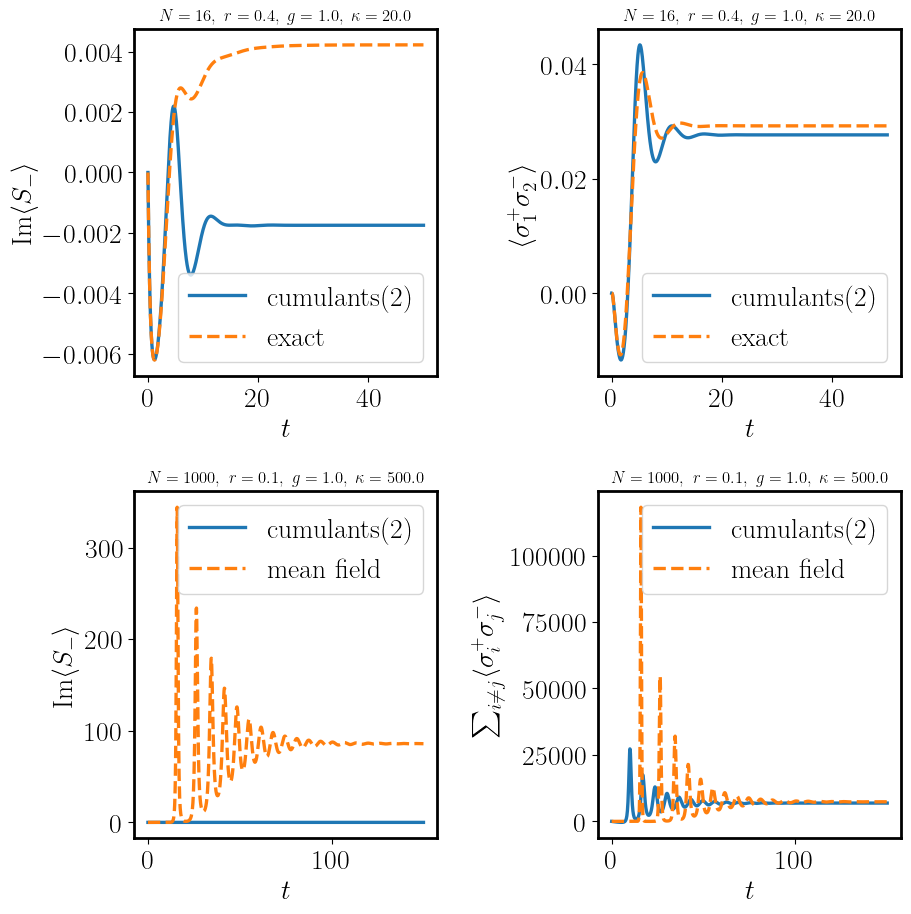

In [4]:
# ============================================================
# 2x2 comparison panel
# top row:    exact vs cumulants(2), small N
# bottom row: mean field vs cumulants(2), large N
# ============================================================

w, h = latex_plot_setup(ratio = 1.0, scale = 2.0)
figure(figsize = (2w, 2h))

# ============================================================
# Small N: exact vs cumulants(2)
# ============================================================

g = 1.0
κ = 20.0
Γ = 4 * g ^ 2 / κ
p = TCParams(N = 16, γ = 0.01 * Γ, r = 2.0 * Γ, g = g, κ = κ, n_phot = 2, Ωspin = 1e-3, Ωcav = 0.0)
tspan = range(0.0, 50.0, 1000)

sum_space, bcav, ψ0, H, J, rates, Sp, Sm, Sz = TavisCummingsModel(p)
tout, ρtot = timeevolution.master(tspan, ψ0, H, J; rates = rates)


mf, sys, u0, p0, obs = TavisCummingsMeanfieldModel(p; order = 2)
prob = ODEProblem(sys, merge(u0, p0), (tspan[1], tspan[end]))

sol = solve(
    prob,
    Tsit5();
    saveat = tspan,
    abstol = 1e-10,
    reltol = 1e-10,
)

Sminus_cum = p.N .* sol[obs.sm1]
Sminus_exact = expect(Sm, ρtot)

SpSm_pair_cum = sol[obs.sp2 * obs.sm1]
SpSm_pair_exact = (
    expect(Sm' * Sm, ρtot)
    .- (expect(Sz, ρtot) .+ p.N) ./ 2
) ./ (p.N * (p.N - 1))

# ------------------
# top left
# ------------------
subplot(2, 2, 1)

plot(sol.t, imag.(Sminus_cum), label = "cumulants(2)")
plot(tout, imag.(Sminus_exact), label = "exact", linestyle = "dashed")

title(@sprintf("\$N=%d,\\ r=%.1f,\\ g=%.1f,\\ \\kappa=%.1f\$", p.N, p.r, p.g, p.κ), fontsize = 12)
xlabel(L"t")
ylabel(L"\operatorname{Im}\langle S_-\rangle")
legend()

# ------------------
# top right
# ------------------
subplot(2, 2, 2)

plot(sol.t, real.(SpSm_pair_cum), label = "cumulants(2)")
plot(tout, real.(SpSm_pair_exact), label = "exact", linestyle = "dashed")

title(@sprintf("\$N=%d,\\ r=%.1f,\\ g=%.1f,\\ \\kappa=%.1f\$", p.N, p.r, p.g, p.κ), fontsize = 12)
xlabel(L"t")
ylabel(L"\langle \sigma_1^+ \sigma_2^- \rangle")
legend()


# ============================================================
# Large N: mean field vs cumulants(2)
# ============================================================

g = 1.0
κ = 500.0
Γ = 4 * g ^ 2 / κ
p = TCParams(N = 1000, γ = 0.01 * Γ, r = 15.0 * Γ, ξ = 0.0, κ = κ, g = g, Ωspin = 1e-6, Ωcav = 0.0)

tspan = range(0.0, 150.0, 1000)

# -----------------
# order 1 mean field
# -----------------
mf1, sys1, u01, p01, obs1 = TavisCummingsMeanfieldModel(p; order = 1)
prob1 = ODEProblem(sys1, merge(u01, p01), (tspan[1], tspan[end]))

sol1 = solve(
    prob1,
    Tsit5();
    saveat = tspan,
    abstol = 1e-10,
    reltol = 1e-10,
)

Sminus1 = p.N .* sol1[obs1.sm1]
SpSm_pair_1 = p.N * (p.N - 1) .* abs2.(sol1[obs1.sm1])

# ------------------
# order 2 cumulants
# ------------------
mf2, sys2, u02, p02, obs2 = TavisCummingsMeanfieldModel(p; order = 2)
prob2 = ODEProblem(sys2, merge(u02, p02), (tspan[1], tspan[end]))

sol2 = solve(
    prob2,
    Tsit5();
    saveat = tspan,
    abstol = 1e-10,
    reltol = 1e-10,
)

Sminus2 = p.N .* sol2[obs2.sm1]
SpSm_pair_2 = p.N * (p.N - 1) .* sol2[obs2.sp2 * obs2.sm1]

# ------------------
# bottom left
# ------------------
subplot(2, 2, 3)

plot(sol2.t, imag.(Sminus2), label = "cumulants(2)")
plot(sol1.t, imag.(Sminus1), label = "mean field", linestyle = "dashed")


title(@sprintf("\$N=%d,\\ r=%.1f,\\ g=%.1f,\\ \\kappa=%.1f\$", p.N, p.r, p.g, p.κ), fontsize = 12)
xlabel(L"t")
ylabel(L"\operatorname{Im}\langle S_-\rangle")
legend()

# ------------------
# bottom right
# ------------------
subplot(2, 2, 4)

plot(sol2.t, real.(SpSm_pair_2), label = "cumulants(2)")
plot(sol1.t, real.(SpSm_pair_1), label = "mean field", linestyle = "dashed")


title(@sprintf("\$N=%d,\\ r=%.1f,\\ g=%.1f,\\ \\kappa=%.1f\$", p.N, p.r, p.g, p.κ), fontsize = 12)
xlabel(L"t")
ylabel(L"\sum_{i\neq j}\langle \sigma_i^+ \sigma_j^-\rangle")
#ylim(bottom = 0.0, top = p.N^2 / 100)
legend()

tight_layout()

savefig("phase_panel.pdf", bbox_inches = "tight")

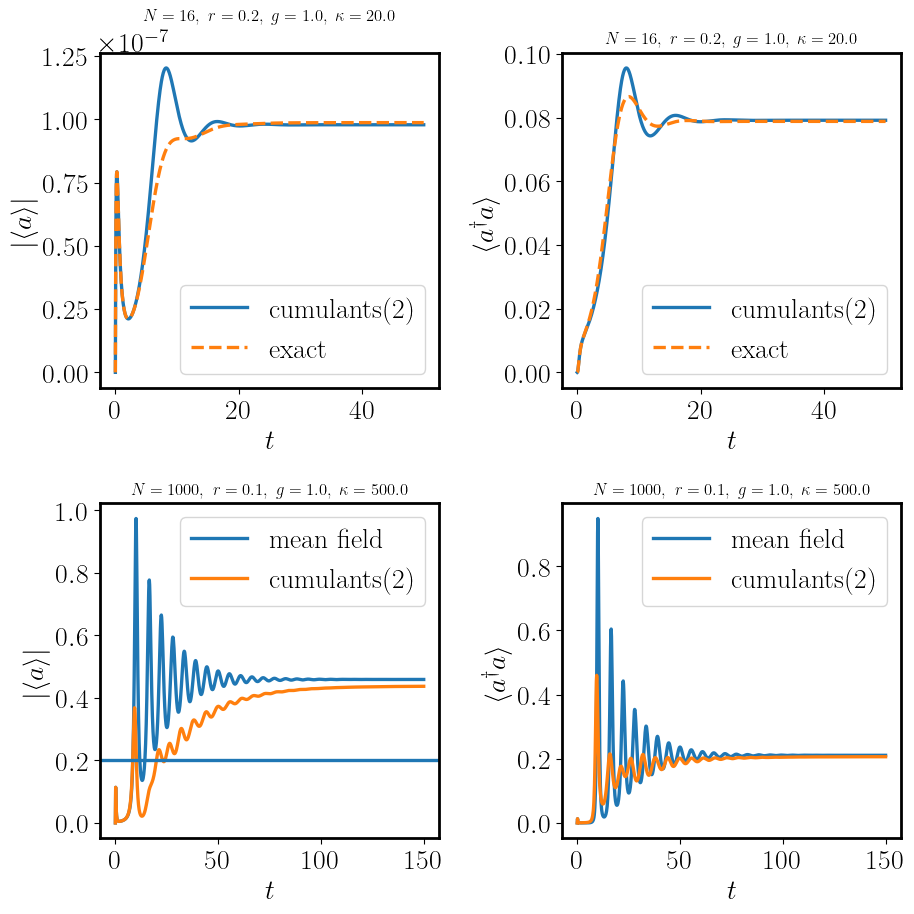

In [5]:
using Printf

panel_title(p) = @sprintf("\$N=%d,\\ r=%.1f,\\ g=%.1f,\\ \\kappa=%.1f\$", p.N, p.r, p.g, p.κ)

function exact_cavity_observables(p, tspan)
    sum_space, bcav, ψ0, H, J, rates, Sp, Sm, Sz = TavisCummingsModel(p)
    a = identityoperator(sum_space) ⊗ destroy(bcav)

    tout, ρtot = timeevolution.master(tspan, ψ0, H, J; rates = rates)

    return tout, expect(a, ρtot), expect(a' * a, ρtot)
end

function mf_cavity_observables(p, tspan; order = 2)
    mf, sys, u0, p0, obs = TavisCummingsMeanfieldModel(p; order = order)

    prob = ODEProblem(sys, merge(u0, p0), (tspan[1], tspan[end]))
    sol = solve(prob, Tsit5(); saveat = tspan, abstol = 1e-10, reltol = 1e-10)

    α = sol[obs.a]
    n = order == 1 ? abs2.(α) : sol[obs.a' * obs.a]

    return sol.t, α, n
end

w, h = latex_plot_setup(ratio = 1.0, scale = 2.0)
figure(figsize = (2w, 2h))

# ============================================================
# Small N: exact vs cumulants(2)
# ============================================================

g = 1.0
κ = 20.0
Γ = 4 * g ^ 2 / κ
p = TCParams(N = 16, γ = 0.01 * Γ, r = 1.0 * Γ, g = g, κ = κ, n_phot = 2, Ωspin = 0.0, Ωcav = 1e-6)
tspan = range(0.0, 50.0, 1000)

tout, α_exact, n_exact = exact_cavity_observables(p, tspan)
tmf, α_cum, n_cum = mf_cavity_observables(p, tspan; order = 2)

subplot(2, 2, 1)
plot(tmf, abs.(α_cum), label = "cumulants(2)")
plot(tout, abs.(α_exact), label = "exact", linestyle = "dashed")
title(panel_title(p), fontsize = 12)
xlabel(L"t")
ylabel(L"\vert\langle a\rangle\vert")
legend()

subplot(2, 2, 2)
plot(tmf, real.(n_cum), label = "cumulants(2)")
plot(tout, real.(n_exact), label = "exact", linestyle = "dashed")
title(panel_title(p), fontsize = 12)
xlabel(L"t")
ylabel(L"\langle a^\dagger a\rangle")
legend()

# ============================================================
# Large N: mean field vs cumulants(2)
# ============================================================

g = 1.0
κ = 500.0
Γ = 4 * g ^ 2 / κ
p = TCParams(N = 1000, γ = 0.01 * Γ, r = 15.0 * Γ, ξ = 0.0, κ = κ, g = g, Ωspin = 0.0, Ωcav = 50)
tspan = range(0.0, 150.0, 1000)

t1, α1, n1 = mf_cavity_observables(p, tspan; order = 1)
t2, α2, n2 = mf_cavity_observables(p, tspan; order = 2)

subplot(2, 2, 3)
plot(t1, abs.(α1), label = "mean field")
plot(t2, abs.(α2), label = "cumulants(2)")
axhline(2* p.Ωcav * g / κ)
title(panel_title(p), fontsize = 12)
xlabel(L"t")
ylabel(L"\vert\langle a\rangle\vert")
legend()

subplot(2, 2, 4)
plot(t1, real.(n1), label = "mean field")
plot(t2, real.(n2), label = "cumulants(2)")
title(panel_title(p), fontsize = 12)
xlabel(L"t")
ylabel(L"\langle a^\dagger a\rangle")
legend()

tight_layout()
savefig("cavity_strong_panel.pdf", bbox_inches = "tight")

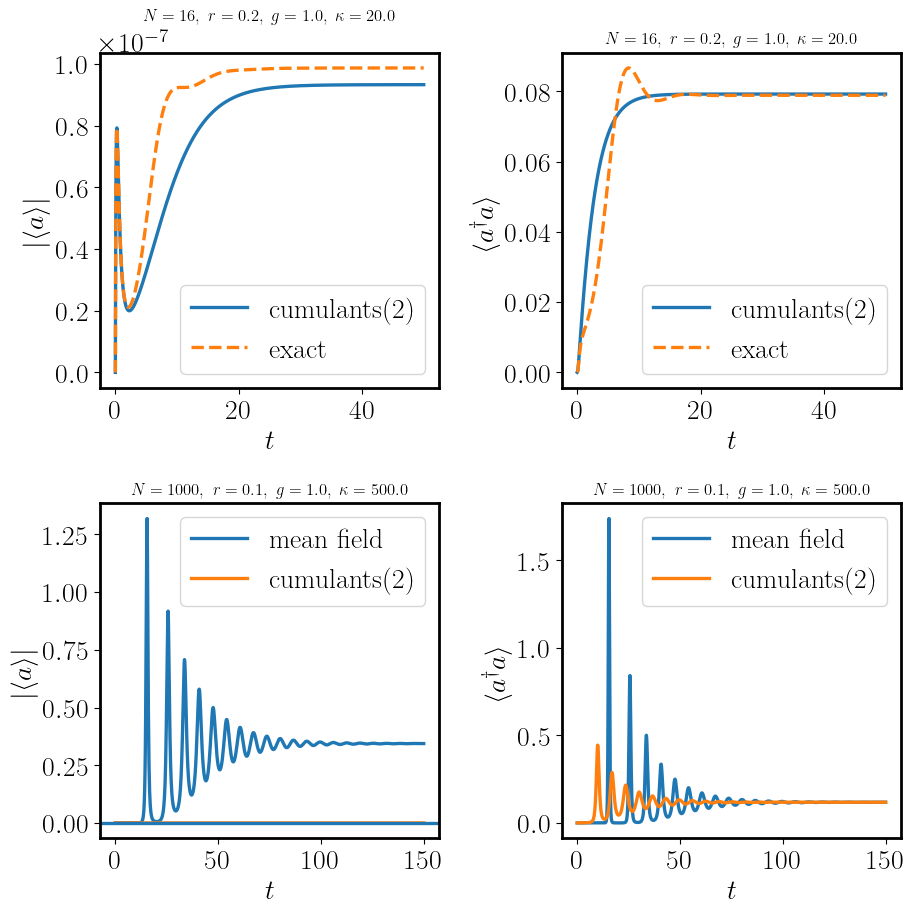

In [24]:
using Printf

panel_title(p) = @sprintf("\$N=%d,\\ r=%.1f,\\ g=%.1f,\\ \\kappa=%.1f\$", p.N, p.r, p.g, p.κ)

function exact_cavity_observables(p, tspan)
    sum_space, bcav, ψ0, H, J, rates, Sp, Sm, Sz = TavisCummingsModel(p)
    a = identityoperator(sum_space) ⊗ destroy(bcav)

    tout, ρtot = timeevolution.master(tspan, ψ0, H, J; rates = rates)

    return tout, expect(a, ρtot), expect(a' * a, ρtot)
end

function mf_cavity_observables(p, tspan; order = 2, mix_choice = maximum)
    mf, sys, u0, p0, obs = TavisCummingsMeanfieldModel(p; order = order, mix_choice = mix_choice)

    prob = ODEProblem(sys, merge(u0, p0), (tspan[1], tspan[end]))
    sol = solve(prob, Tsit5(); saveat = tspan, abstol = 1e-10, reltol = 1e-10)

    α = sol[obs.a]
    n = order == 1 ? abs2.(α) : sol[obs.a' * obs.a]

    return sol.t, α, n
end

w, h = latex_plot_setup(ratio = 1.0, scale = 2.0)
figure(figsize = (2w, 2h))

# ============================================================
# Small N: exact vs cumulants(2)
# ============================================================

g = 1.0
κ = 20.0
Γ = 4 * g ^ 2 / κ
p = TCParams(N = 16, γ = 0.01 * Γ, r = 1.0 * Γ, g = g, κ = κ, n_phot = 2, Ωspin = 0.0, Ωcav = 1e-6)
tspan = range(0.0, 50.0, 1000)

tout, α_exact, n_exact = exact_cavity_observables(p, tspan)
tmf, α_cum, n_cum = mf_cavity_observables(p, tspan; order = [2,1], mix_choice = x->2)

subplot(2, 2, 1)
plot(tmf, abs.(α_cum), label = "cumulants(2)")
plot(tout, abs.(α_exact), label = "exact", linestyle = "dashed")
title(panel_title(p), fontsize = 12)
xlabel(L"t")
ylabel(L"\vert\langle a\rangle\vert")
legend()

subplot(2, 2, 2)
plot(tmf, real.(n_cum), label = "cumulants(2)")
plot(tout, real.(n_exact), label = "exact", linestyle = "dashed")
title(panel_title(p), fontsize = 12)
xlabel(L"t")
ylabel(L"\langle a^\dagger a\rangle")
legend()

# ============================================================
# Large N: mean field vs cumulants(2)
# ============================================================

g = 1.0
κ = 500.0
Γ = 4 * g ^ 2 / κ
p = TCParams(N = 1000, γ = 0.01 * Γ, r = 15.0 * Γ, ξ = 0.0, κ = κ, g = g, Ωspin = 0.0, Ωcav = 1e-3)
tspan = range(0.0, 150.0, 1000)

t1, α1, n1 = mf_cavity_observables(p, tspan; order = 1)
t2, α2, n2 = mf_cavity_observables(p, tspan; order = 2)

subplot(2, 2, 3)
plot(t1, abs.(α1), label = "mean field")
plot(t2, abs.(α2), label = "cumulants(2)")
axhline(2* p.Ωcav * g / κ)
title(panel_title(p), fontsize = 12)
xlabel(L"t")
ylabel(L"\vert\langle a\rangle\vert")
legend()

subplot(2, 2, 4)
plot(t1, real.(n1), label = "mean field")
plot(t2, real.(n2), label = "cumulants(2)")
title(panel_title(p), fontsize = 12)
xlabel(L"t")
ylabel(L"\langle a^\dagger a\rangle")
legend()

tight_layout()
savefig("cavity_weak_panel.pdf", bbox_inches = "tight")

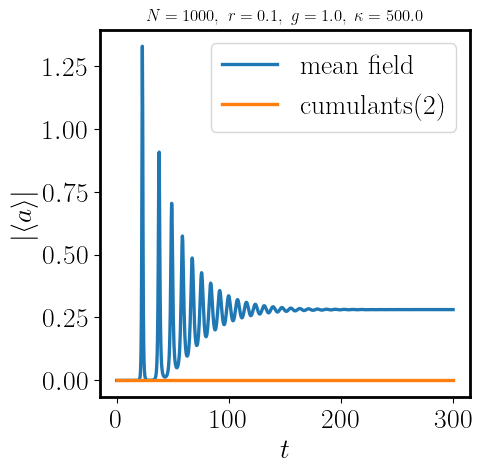

PyObject <matplotlib.legend.Legend object at 0x38b425400>

In [7]:
g = 1.0
κ = 500.0
Γ = 4 * g ^ 2 / κ
p = TCParams(N = 1000, γ = 0.01 * Γ, r = 10.0 * Γ, ξ = 0.0, κ = κ, g = g, Ωspin = 0.0, Ωcav = 1e-6)
tspan = range(0.0, 300.0, 1000)

t1, α1, n1 = mf_cavity_observables(p, tspan; order = 1)
t2, α2, n2 = mf_cavity_observables(p, tspan; order = 2)

plot(t1, abs.(α1), label = "mean field")
plot(t2, abs.(α2), label = "cumulants(2)")
title(panel_title(p), fontsize = 12)
xlabel(L"t")
ylabel(L"\vert\langle a\rangle\vert")
legend()

In [55]:
g = 1.0
κ = 20.0
Γ = 4 * g ^ 2 / κ
p = TCParams(N = 8, γ = 0.01 * Γ, r = 2.0 * Γ, g = g, κ = κ, n_phot = 2, Ωspin = 0.0, Ωcav = 0.0)
tspan = range(0.0, 50.0, 1000)

sum_space, bcav, ψ0, H, J, rates, Sp, Sm, Sz = TavisCummingsModel(p)
vals, vecs = steadystate.liouvillianspectrum(H, J; rates = rates, nev = 10)

(ComplexF64[-9.715663846236303e-16 - 1.3661808837095733e-16im, -0.24664002682941064 + 1.9511687737055746e-16im, -0.24664002682941974 - 2.8024085059908527e-16im, -0.24864843631647904 + 2.0658830362216696e-15im, -0.24864843631648803 - 6.341972845318178e-16im, -0.335312484322107 + 8.133524985953583e-16im, -0.33531248432212707 - 1.0061322573745398e-16im, -0.47210187082136684 - 3.165707521340687e-16im, -0.4654521126014429 + 0.6325809317657513im, -0.4654521126014497 - 0.6325809317657695im], DenseOpType[Operator(dim=75x75)
  basis: [[Spin(4) ⊕ Spin(3) ⊕ Spin(2) ⊕ Spin(1) ⊕ Spin(0)] ⊗ Fock(cutoff=2)]
 -0.0115532+0.105356im     5.0e-17+9.0e-17im    …          0.0-0.0im
    4.0e-17-1.9e-16im   -0.0100313+0.0914771im             0.0-0.0im
    1.0e-17+1.0e-17im      5.0e-17-2.1e-16im              -0.0-0.0im
   -2.0e-17+0.0im          2.0e-17+1.0e-17im               0.0-0.0im
   -1.0e-17-0.0im         -3.0e-17+0.0im                   0.0+0.0im
    1.0e-17-1.0e-17im     -2.0e-17+1.0e-17im    …      

N = 8
N = 10
N = 12
N = 14
N = 

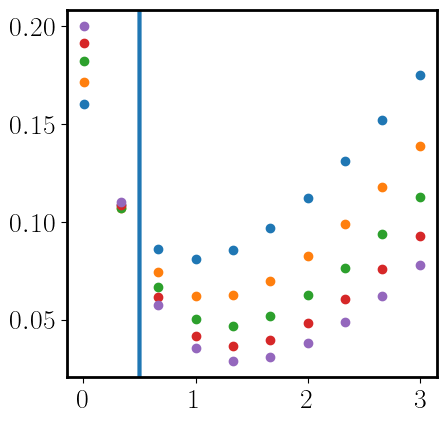

16


In [86]:
for N in [8,10,12,14,16]#[8,10,12,14,16]
    @show N

    res = []
    γs = range(0.001, 3.0, 10)
    for γ in γs .* Γ
        p = TCParams(N = N, γ = γ, r = 0.5 * Γ, g = g, κ = κ, n_phot = 2, Ωspin = 0.0, Ωcav = 0.0)
        sum_space, bcav, ψ0, H, J, rates, Sp, Sm, Sz = TavisCummingsModel(p)
        vals, vecs = steadystate.liouvillianspectrum(H, J; rates = rates, nev = 5, maxiter = 5000, tol = 1e-10)
        Δ = abs(vals[2]-vals[1])
        push!(res, Δ)
    end

    scatter(γs, res)
    axvline(0.5)
end

In [144]:
using QuantumOptics
using LinearAlgebra
using SparseArrays

function susceptibility_linear_response(H0, jumps, rates, rho0, H1, Olist)
    # Build Liouvillian at zero drive
    L = liouvillian(H0, jumps; rates = rates)
    Lmat = L.data

    # Source term: L0 rho1 = i[H1, rho0]
    b_op = 1im * (H1 * rho0 - rho0 * H1)
    b = vec(Matrix(dense(b_op).data))

    # Enforce Tr(rho1)=0 by replacing one equation.
    # This removes the singular steady-state nullspace.
    d = size(rho0, 1)
    trace_row = zeros(ComplexF64, d^2)

    for n in 1:d
        trace_row[n + (n - 1) * d] = 1.0
    end

    A = copy(Lmat)
    rhs = copy(b)

    A[1, :] .= trace_row
    rhs[1] = 0.0

    rho1_vec = A \ rhs
    rho1_mat = reshape(rho1_vec, d, d)

    rho1 = Operator(rho0.basis_l, rho0.basis_r, rho1_mat)

    chis = [tr(O * rho1) for O in Olist]

    return rho1, chis
end


chi_S_spins = []
chi_a_spins = []
chi_a_cavs = []
chi_S_cavs = []

Ns = [8,9,10,11,12,13,14,15,16]

for N in Ns
    # zero-drive parameters
    p0 = TCParams(N = N, γ = 0.0, r = Γ/2, g = g, κ = κ, n_phot = 2, Ωspin = 0.0, Ωcav = 0.0)

    sum_space, bcav, ψ0, H0, J, rates, Sp, Sm, Sz = TavisCummingsModel(p0)

    times, (rhoinit, rho0) = steadystate.master(H0, J; rates = rates)

    # H1 for Omega_spin.
    # Sign convention chosen to match ds/dt = i(2pe-1) Omega_spin.
    a = J[end]
    Hspin = Sp + Sm

    rho1_spin, (chi_S_spin, chi_a_spin) = susceptibility_linear_response(H0, J, rates, rho0, Hspin, [Sm,a])

    Hcav = a + dagger(a)
    rho1_cav, (chi_a_cav, chi_S_cav) =susceptibility_linear_response(H0, J, rates, rho0, Hcav, [a, Sm])

    push!(chi_S_spins, chi_S_spin)
    push!(chi_a_spins, chi_a_spin)
    push!(chi_a_cavs, chi_a_cav)
    push!(chi_S_cavs, chi_S_cav)

end


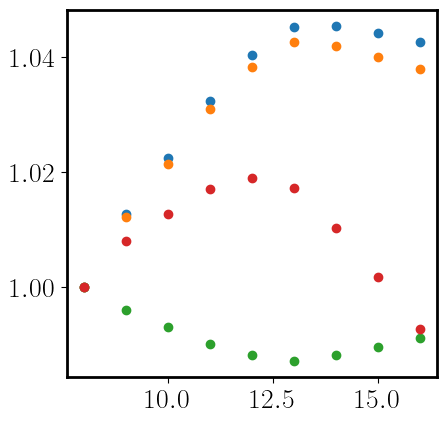

PyObject <matplotlib.collections.PathCollection object at 0x3d94ecf50>

In [147]:
scatter(Ns, abs.(chi_S_spins / chi_S_spins[1]))
scatter(Ns, abs.(chi_a_spins / chi_a_spins[1]))
scatter(Ns, abs.(chi_a_cavs / chi_a_cavs[1]))
scatter(Ns, abs.(chi_S_cavs / chi_S_cavs[1]))

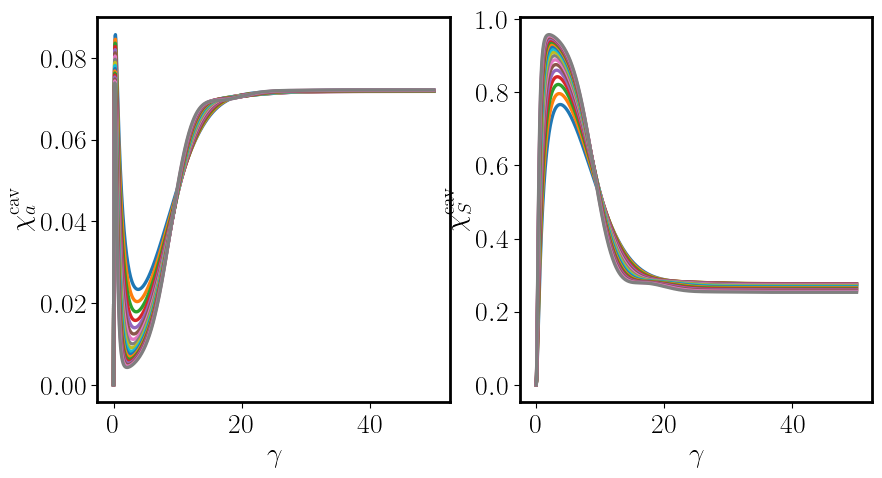

In [160]:
g = 1.0
κ = 20.0
Γ = 4 * g ^ 2 / κ

function exact_observables(p, tspan)
    sum_space, bcav, ψ0, H, J, rates, Sp, Sm, Sz = TavisCummingsModel(p)
    a = identityoperator(sum_space) ⊗ destroy(bcav)

    tout, ρtot = timeevolution.master(tspan, ψ0, H, J; rates = rates)

    return tout, expect(a, ρtot), expect(a' * a, ρtot), expect(Sm, ρtot), expect(Sm' * Sm, ρtot)
end

fig, (ax1, ax2) = subplots(ncols = 2, figsize = (10,5))

for N in range(8,25)
    p = TCParams(N = N, γ = 0.01 * Γ, r = Γ/2, g = g, κ = κ, n_phot = 2, Ωspin = 0.0, Ωcav = 1e-3)
    tspan = range(0.0, 50.0, 1000)

    tout, α_exact, n_exact, sm_exact, se_exact = exact_observables(p, tspan)

    ax1.plot(tout, abs.(α_exact) / p.Ωcav)
    ax2.plot(tout, abs.(sm_exact) / p.Ωcav)
end

ax1.set_xlabel(L"\gamma")
ax1.set_ylabel(L"\chi_a^{\rm{cav}}")

ax2.set_xlabel(L"\gamma")
ax2.set_ylabel(L"\chi_S^{\rm{cav}}")
savefig("spin_sus.pdf", bbox_inches = "tight")

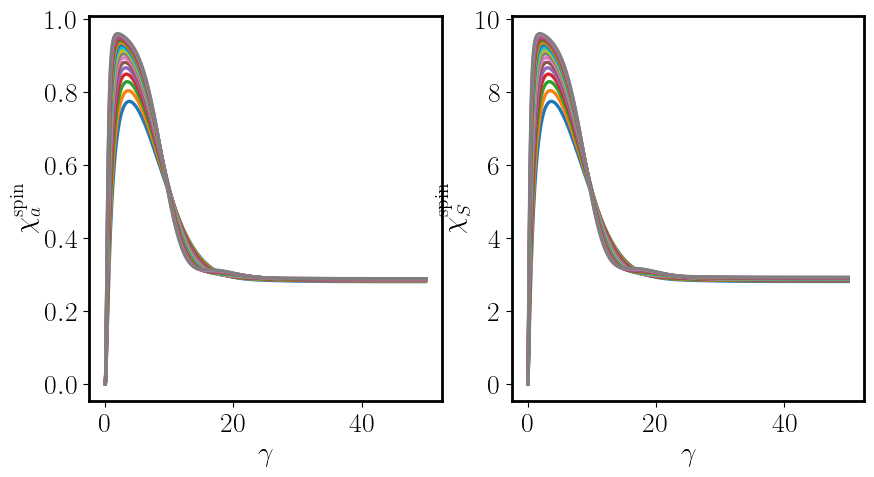

: 

In [ ]:
fig, (ax1, ax2) = subplots(ncols = 2, figsize = (10,5))

for N in range(8,25)
    p = TCParams(N = N, γ = 0.01 * Γ, r = Γ/2, g = g, κ = κ, n_phot = 2, Ωspin = 1e-3, Ωcav = 0.0)
    tspan = range(0.0, 50.0, 1000)

    tout, α_exact, n_exact, sm_exact, se_exact = exact_observables(p, tspan)

    ax1.plot(tout, abs.(α_exact) / p.Ωspin)
    ax2.plot(tout, abs.(sm_exact) / p.Ωspin)
end

ax1.set_xlabel(L"\gamma")
ax1.set_ylabel(L"\chi_a^{\rm{spin}}")

ax2.set_xlabel(L"\gamma")
ax2.set_ylabel(L"\chi_S^{\rm{spin}}")
savefig("cav_sus.pdf", bbox_inches = "tight")